# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
df = pd.read_csv("/content/listings.csv.gz", low_memory=False)

df.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,934859141300145599,https://www.airbnb.com/rooms/934859141300145599,20260622055616,2026-07-02,previous scrape,An Exquisite Rooftop Studio,Introducing an exquisite rooftop studio in the...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,384892315,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
1,944156894640610027,https://www.airbnb.com/rooms/944156894640610027,20260622055616,2026-06-23,city scrape,Tarrytown bungalow,Take a break and unwind at this peaceful oasis...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,13392053,...,5.00,4.75,4.25,NaN,NaN,1,0,1,0,0.12
2,1634902892490996951,https://www.airbnb.com/rooms/1634902892490996951,20260622055616,2026-06-23,city scrape,Central East Gem near running trail,Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,266329439,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
3,1308737991593278409,https://www.airbnb.com/rooms/1308737991593278409,20260622055616,2026-06-23,city scrape,Empire,"- Accommodate up to 14 guests, 4-bedroom home<...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,398748229,...,4.93,4.80,4.61,OL2023119758,NaN,4,4,0,0,2.39
4,574582741829434703,https://www.airbnb.com/rooms/574582741829434703,20260622055616,2026-06-23,city scrape,Galaxy by AvantStay | Luxury Amenities in Austin,- Pet-friendly home<br />- Rooftop pool and lo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,434308464,...,4.52,4.97,4.90,NaN,NaN,178,178,0,0,0.60


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

neighborhood_overview                           11295
host_since                                      11295
host_response_time                              11295
host_thumbnail_url                              11295
host_acceptance_rate                            11295
                                                ...  
availability_30                                     0
calculated_host_listings_count                      0
calculated_host_listings_count_entire_homes         0
calculated_host_listings_count_private_rooms        0
calculated_host_listings_count_shared_rooms         0
Length: 90, dtype: int64


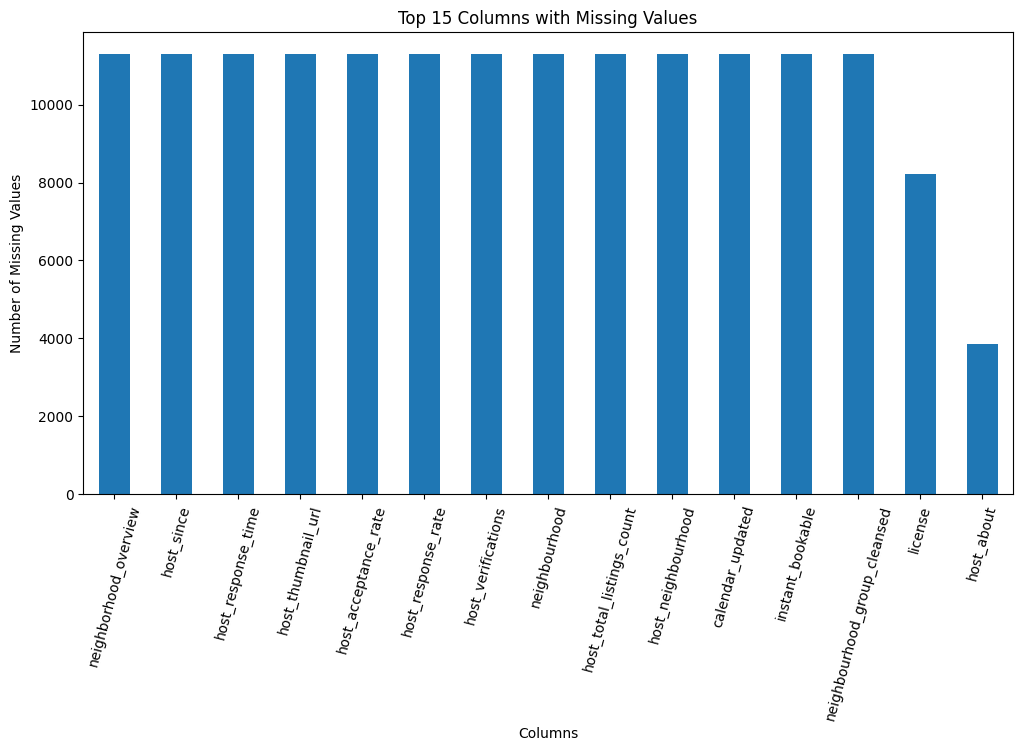

In [12]:
# Count null values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)

print(missing_values)

# Show the 15 columns with the most missing values
plt.figure(figsize=(12, 6))
missing_values.head(15).plot(kind="bar")

plt.title("Top 15 Columns with Missing Values")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=75)
plt.show()


### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. As it shows in the table, almost all of them have 11,295. The first three on the chart are neighborhood_overview, host_since, and host_response_time.

2. I think that host_since and host_response_time are likely to create business issues because they are needed for the hosts responding for all of the values.

3. I think the calendar_ignored and the host_thumbnail_url could be dropped because those don't give relevant information.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [13]:
# Drop 3 columns from my dataset
df = df.drop(columns=[
    "host_thumbnail_url",
    "calendar_updated",
    "host_verifications",
    "neighbourhood_group_cleansed"
])

# Confirm they're gone
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11295 entries, 0 to 11294
Data columns (total 86 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            11295 non-null  int64  
 1   listing_url                                   11295 non-null  object 
 2   scrape_id                                     11295 non-null  int64  
 3   last_scraped                                  11295 non-null  object 
 4   source                                        11295 non-null  object 
 5   name                                          11295 non-null  object 
 6   description                                   11111 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   11295 non-null  object 
 9   host_id                                       11295 non-null 

### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I dropped the host_thumbail_url, calendar_updated, and neighborhood_group_cleansed.

2. From a business perspective, they were not useful because every row had a missing value, meaning there was no relevant information to put into analysis.

3. If I left them in, I think I would create clutter and confusion. It would probably show that in a visualization model.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [15]:
# Fill missing bedrooms with the median
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())

# Fill missing review scores with the median
df["review_scores_rating"] = df["review_scores_rating"].fillna(
    df["review_scores_rating"].median()
)

# Check that missing values were filled
print(df[["bedrooms", "review_scores_rating"]].isnull().sum())


bedrooms                0
review_scores_rating    0
dtype: int64


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. I cleaned the bedrooms and reiew_scores_rating columns.

2. I filled the missing values using the median for both of the columns because it is useful (less affected by extreme values) and it also gives a reasonable representation for a general listing.

3. The main risk with using the median would probably be that it doesn't show the actual, true value which can make listings look similar when they're really not.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

In [23]:
# Remove dollar signs and commas from price
df["price"] = df["price"].str.replace("$", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)

# Convert price to numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Check the cleaned column
print(df["price"].describe())

count    10321.000000
mean       352.247362
std        828.970064
min          7.950000
25%        133.100000
50%        217.000000
75%        363.000000
max      58600.500000
Name: price, dtype: float64


### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I fixed the price column

2. I removed dollar signs and commas from the prices and then converted the price to numeric

3. This will help solve calculations like averages, medians, and comparisons muc easier. And it makes the columns easy to use for visualizations if needed.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [24]:
# Check for rows that are exact duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check for duplicate listing IDs
print("Duplicate IDs:", df["id"].duplicated().sum())

# Remove duplicates if found
df = df.drop_duplicates()
df = df.drop_duplicates(subset="id", keep="first")

Duplicate rows: 0
Duplicate IDs: 0


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. No, I actually found 0 duplicates.

2. I checked for duplicate and unique listing IDs and since there was 0, I kept all of them.

3. Duplicates can be risky for Airbnb teams because this can give them a higher cout of properties (when it really isn't) which can give them the wrong average prices and availability.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [27]:
df.to_csv("cleaned_airbnb_data_6.csv", index=False)

## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. I think the most challenging part was what to do with the missing values because certains columns needed certain decisions because I didn't know which ones to keep, remove, or fill.
2. I had to drop the host_thumbanil_url and calendar_updated. It was necessary to drop because they had empty columns which would give no useful information whatsoever.
3. One way a business team might benefit from the cleaned version of this data is that pricing would be easier to understand and solve because everything is now numeric.
4. If I had more time, I would look at the rest of the missing values and I would see if there's any extreme values.
5. This relates to my learning outcomes of "building and evaluating data that forecasts revenue to guide budgeting or investment decisions" that I created on canvas. Cleaning data will help create accurate data in the future.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"